# Tratamento dos dados

Dado que uma rede MLP espera como entrada um vetor unidimensional de características, é necessário adequar a representação das imagens da base de dados para esse formato.

Para isso, aplicaram-se as seguintes etapas de pré-processamento:

1. Conversão das imagens de RGB para escala de cinza, removendo os canais de cor e mantendo apenas a intensidade dos pixels, o que reduz a dimensionalidade dos dados.

2. *Flatten* das imagens para representação em linha, transformando a matriz bidimensional da imagem em um vetor unidimensional de características.

In [1]:
# Imports

from keras.datasets import cifar10
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.utils import set_random_seed, to_categorical
from keras.optimizers import Adam

set_random_seed(259)

In [2]:
# Carregamento dos dados

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print('Train Images Shape:      ', x_train.shape)
print('Train Labels Shape:      ', y_train.shape)

print('\nTest Images Shape:       ', x_test.shape)
print('Test Labels Shape:       ', y_test.shape)

Train Images Shape:       (50000, 32, 32, 3)
Train Labels Shape:       (50000, 1)

Test Images Shape:        (10000, 32, 32, 3)
Test Labels Shape:        (10000, 1)


/Users/ctn/code/tempo/CIFAR10/.venv/lib/python3.12/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


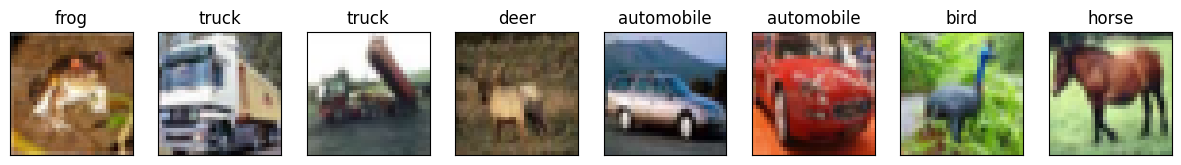

In [3]:
# Exemplos de imagens

# Classes
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(15,15))

# Loop over the first 8 images
for i in range(8):
    # Create a subplot for each image
    plt.subplot(8, 8, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)

    # Display the image
    plt.imshow(x_train[i])

    # Set the label as the title
    plt.title(class_names[y_train[i][0]], fontsize=12)

# Display the figure
plt.show()

In [4]:
# Conversão das imagens de RGB para escala de cinza

# fórmula padrão: Y = 0.299 R + 0.587 G + 0.114 B
x_train_gray = np.dot(x_train[..., :3], [0.299, 0.587, 0.114])
x_test_gray = np.dot(x_test[..., :3], [0.299, 0.587, 0.114])

print('Train Images Shape (Gray scale):      ', x_train_gray.shape)
print('Test Images Shape (Gray scale):       ', x_test_gray.shape)

Train Images Shape (Gray scale):       (50000, 32, 32)
Test Images Shape (Gray scale):        (10000, 32, 32)


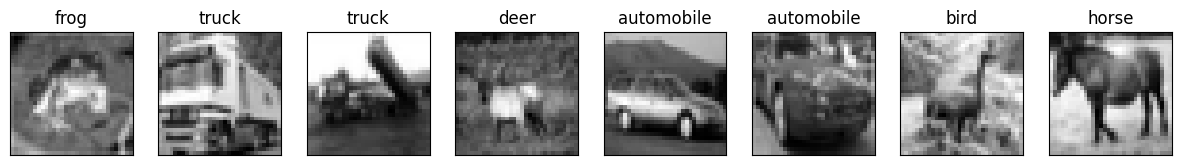

In [5]:
# Exemplos de imagens

# Classes
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(15,15))

# Loop over the first 8 images
for i in range(8):
    # Create a subplot for each image
    plt.subplot(8, 8, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)

    # Display the image
    plt.imshow(x_train_gray[i], cmap='gray')

    # Set the label as the title
    plt.title(class_names[y_train[i][0]], fontsize=12)

# Display the figure
plt.show()

In [6]:
# Flatten das imagens e normalização [0, 1] (melhora estabilidade e acurácia)

x_train_flat = x_train_gray.reshape(x_train_gray.shape[0], -1).astype('float32') / 255.0
x_test_flat = x_test_gray.reshape(x_test_gray.shape[0], -1).astype('float32') / 255.0

x_train_df = pd.DataFrame(x_train_flat)
x_test_df = pd.DataFrame(x_test_flat)

print('Train Images Shape (Gray scale & Flatten):      ', x_train_df.shape)
print('Test Images Shape (Gray scale & Flatten):       ', x_test_df.shape)

# Conversão dos rótulos para one-hot encoding

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

Train Images Shape (Gray scale & Flatten):       (50000, 1024)
Test Images Shape (Gray scale & Flatten):        (10000, 1024)


# Estrutura da rede

In [7]:
# Hiper-parâmetros

input_shape = 1024                  # 32 x 32 x 1
epochs = 50                         # https://keras.io/examples/vision/mlp_image_classification/
batch_size = 128                    # https://wandb.ai/sulbing/CIFAR10/reports/CIFAR10-Only-MLP-Not-CNN---Vmlldzo1NjkyNjMw
dropout_rate = 0.2                  # https://keras.io/examples/vision/mlp_image_classification/
learning_rate = 0.001               # https://wandb.ai/sulbing/CIFAR10/reports/CIFAR10-Only-MLP-Not-CNN---Vmlldzo1NjkyNjMw

#Outras Fontes
#https://pvss.github.io/MLP+of+CIFAR-10
#https://www.kaggle.com/code/yorkyong/exploring-cifar-10-w-mlp-cnn-resnet

In [ ]:
# Construção do modelo MLP

# Estutura baseada no artigo
# "UTILIZAÇÃO DE REDES NEURAIS ARTIFICIAIS PARA A CLASSIFICAÇÃO DECORROSÃO POR PITE OBSERVADAS EM IMAGENS OBTIDAS COM O ENSAIO NÃO INVASIVO DE QUEDA DE POTENCIAL"
# de GABRIEL PEREIRA HOLANDA BARRETO (https://repositorio.ufc.br/bitstream/riufc/83115/1/2025_tcc_gphbarreto.pdf)

def create_model_1():

    model = Sequential([
        Dense(32, activation='relu', input_shape=(input_shape,)),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy'],
    )

    return model

# Experimento 1 - Sem dropout e sem early stop

In [32]:
histories = []
train_accuracies = []
test_losses = []
test_accuracies = []

for i in range(3):
    model_1 = create_model_1()

    history = model_1.fit(
        x_train_df.values,
        y_train_cat,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.1,
        verbose=1,
    )

    histories.append(history)

    train_acc = history.history['accuracy'][-1] 
    train_accuracies.append(train_acc)          

    loss, acc = model_1.evaluate(
        x_test_df.values,
        y_test_cat,
        verbose=0
    )

    test_losses.append(loss)
    test_accuracies.append(acc)

    print(f'Execução {i+1} | Treino — acurácia: {train_acc:.4f} | Teste — loss: {loss:.4f}, acurácia: {acc:.4f}')

Epoch 1/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2572 - loss: 2.0449 - val_accuracy: 0.3176 - val_loss: 1.9427
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3213 - loss: 1.8965 - val_accuracy: 0.3456 - val_loss: 1.8493
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3478 - loss: 1.8325 - val_accuracy: 0.3582 - val_loss: 1.8175
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3652 - loss: 1.7885 - val_accuracy: 0.3758 - val_loss: 1.7765
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3796 - loss: 1.7525 - val_accuracy: 0.3820 - val_loss: 1.7467
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3922 - loss: 1.7183 - val_accuracy: 0.3926 - val_loss: 1.7266
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4031 - loss: 1.6883 - val_accuracy: 0.3948 - val_loss: 1.7107
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4128 - loss: 1.6595 - val_accuracy: 0.

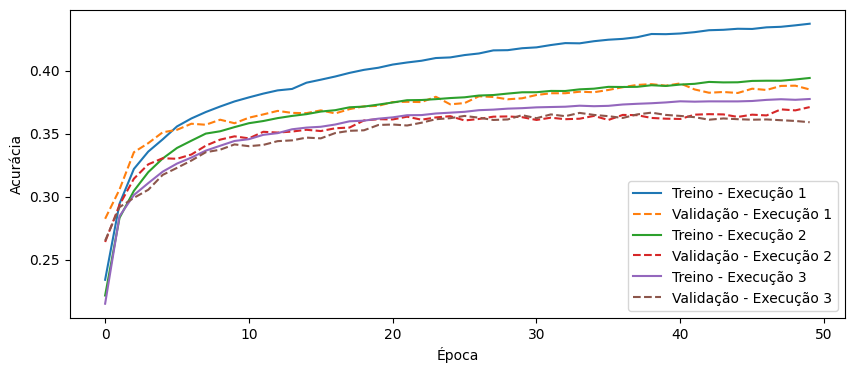

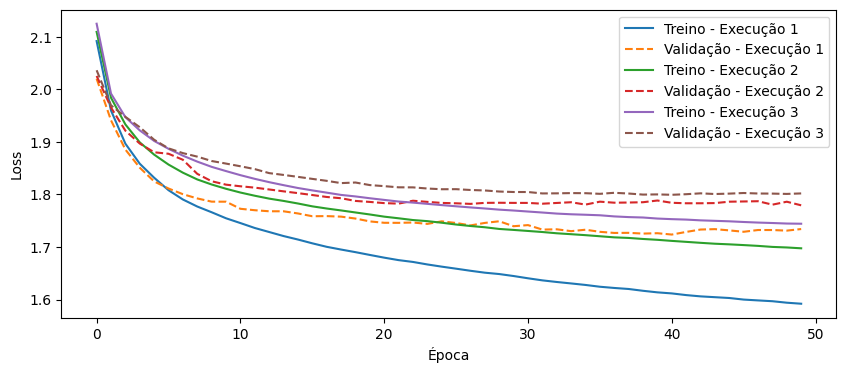

Execução 1:
  Treino — acurácia: 0.4372
  Teste  — loss: 1.7472, acurácia: 0.3850
Execução 2:
  Treino — acurácia: 0.3941
  Teste  — loss: 1.7789, acurácia: 0.3649
Execução 3:
  Treino — acurácia: 0.3774
  Teste  — loss: 1.7933, acurácia: 0.3601


In [10]:
# Acurácia de validação e teste
def show_results(histories, train_accuracies, test_losses, test_accuracies):
    plt.figure(figsize=(10,4))

    for i, history in enumerate(histories):
        plt.plot(history.history['accuracy'], label=f'Treino - Execução {i+1}')
        plt.plot(history.history['val_accuracy'], '--', label=f'Validação - Execução {i+1}')

    plt.xlabel('Época')
    plt.ylabel('Acurácia')
    plt.legend()
    plt.show()

    # Perda de validação e teste

    plt.figure(figsize=(10,4))

    for i, history in enumerate(histories):
        plt.plot(history.history['loss'], label=f'Treino - Execução {i+1}')
        plt.plot(history.history['val_loss'], '--', label=f'Validação - Execução {i+1}')

    plt.xlabel('Época')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    # Resultado do experimento
    for i in range(3):
        print(f'Execução {i+1}:')
        print(f'  Treino — acurácia: {train_accuracies[i]:.4f}')
        print(f'  Teste  — loss: {test_losses[i]:.4f}, acurácia: {test_accuracies[i]:.4f}')

show_results(histories, train_accuracies, test_losses, test_accuracies)

# Experimento 2 - Sem dropout e com early stop

In [11]:
# Treinamento

from keras.callbacks import EarlyStopping

histories = []
train_accuracies = []
test_losses = []
test_accuracies = []

for i in range(3):
    model_1 = create_model_1()

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=5,
    )

    history = model_1.fit(
        x_train_df.values,
        y_train_cat,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.1,
        verbose=1,
        callbacks=[early_stop]
    )

    histories.append(history)

    train_acc = history.history['accuracy'][-1] 
    train_accuracies.append(train_acc)          

    loss, acc = model_1.evaluate(
        x_test_df.values,
        y_test_cat,
        verbose=0
    )

    test_losses.append(loss)
    test_accuracies.append(acc)

    print(f'Execução {i+1} | Treino — acurácia: {train_acc:.4f} | Teste — loss: {loss:.4f}, acurácia: {acc:.4f}')

Epoch 1/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.2291 - loss: 2.0943 - val_accuracy: 0.2766 - val_loss: 2.0055
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 867us/step - accuracy: 0.2952 - loss: 1.9585 - val_accuracy: 0.3120 - val_loss: 1.9337
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3130 - loss: 1.9160 - val_accuracy: 0.3184 - val_loss: 1.9085
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 903us/step - accuracy: 0.3207 - loss: 1.8898 - val_accuracy: 0.3266 - val_loss: 1.8883
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 898us/step - accuracy: 0.3322 - loss: 1.8659 - val_accuracy: 0.3324 - val_loss: 1.8681
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 900us/step - accuracy: 0.3408 - loss: 1.8468 - val_accuracy: 0.3394 - val_loss: 1.8542
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 928us/step - accuracy: 0.3477 - loss: 1.8314 - val_accuracy: 0.3420 - val_loss: 1.8425
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 925us/step - accuracy: 0.3523 - loss: 1.8192 - val_

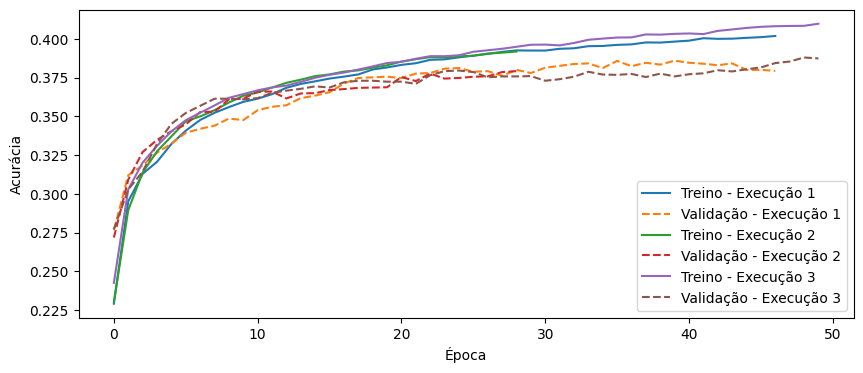

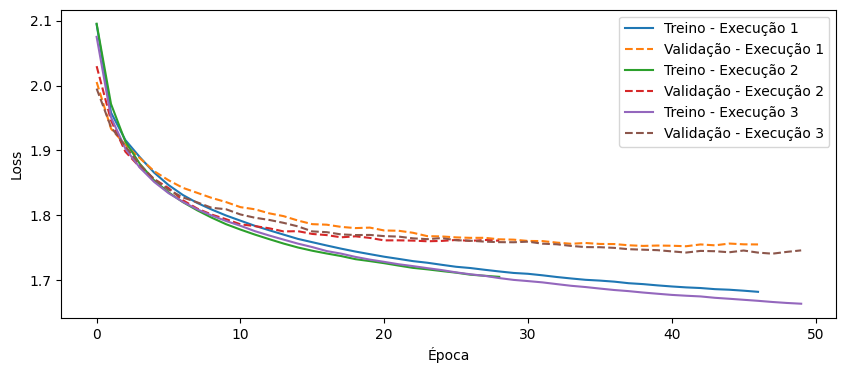

Execução 1:
  Treino — acurácia: 0.4019
  Teste  — loss: 1.7612, acurácia: 0.3793
Execução 2:
  Treino — acurácia: 0.3918
  Teste  — loss: 1.7739, acurácia: 0.3707
Execução 3:
  Treino — acurácia: 0.4098
  Teste  — loss: 1.7574, acurácia: 0.3734


In [12]:
# Resutados
show_results(histories, train_accuracies, test_losses, test_accuracies)

# Experimento 3 - Com dropout e sem early stop

In [13]:
# Treinamento

In [14]:
# Resultados

# Experimento 4 - Com dropout e com early stop

In [51]:
# Construção do modelo MLP

# Utilizamos inicialmente um drop_out de 0.5 mas descobrimos que o resultado é relativamente alto para uma
# quantidade baixa de camadase neuronios, aumentar os neuronios e camadas nao pareceu favorecer o treinamento

# dropout_rate de 0.05

def create_model_4():

    model = Sequential([
        Dense(32, activation='relu', input_shape=(input_shape,)),
        Dropout(0.05),
        Dense(64, activation='relu'),
        Dropout(0.05),
        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy'],
    )

    return model

In [52]:
# Treinamento
from keras.callbacks import EarlyStopping

histories = []
train_accuracies = []
test_losses = []
test_accuracies = []

for i in range(3):
    model_4 = create_model_4()

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=5,
    )

    history = model_4.fit(
        x_train_df.values,
        y_train_cat,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.1,
        verbose=0,
        callbacks=[early_stop]
    )

    histories.append(history)

    train_acc = history.history['accuracy'][-1] 
    train_accuracies.append(train_acc)          

    loss, acc = model_4.evaluate(
        x_test_df.values,
        y_test_cat,
        verbose=0
    )

    test_losses.append(loss)
    test_accuracies.append(acc)

    print(f'Execução {i+1} | Treino — acurácia: {train_acc:.4f} | Teste — loss: {loss:.4f}, acurácia: {acc:.4f}')

/Users/ctn/code/tempo/CIFAR10/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Execução 1 | Treino — acurácia: 0.3716 | Teste — loss: 1.7493, acurácia: 0.3729
Execução 2 | Treino — acurácia: 0.3627 | Teste — loss: 1.7786, acurácia: 0.3668
Execução 3 | Treino — acurácia: 0.3641 | Teste — loss: 1.7846, acurácia: 0.3619


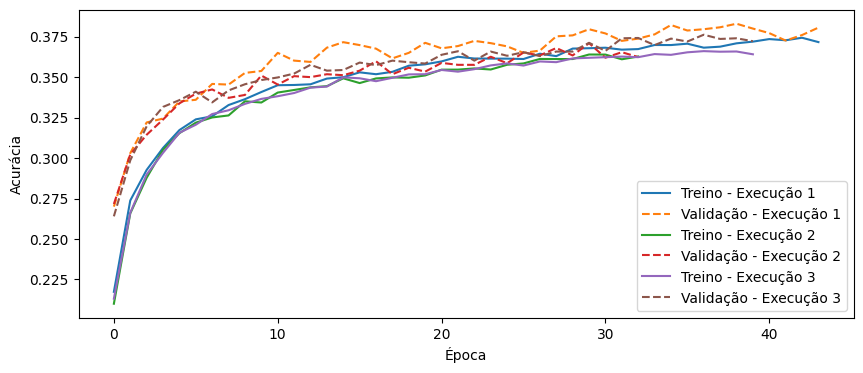

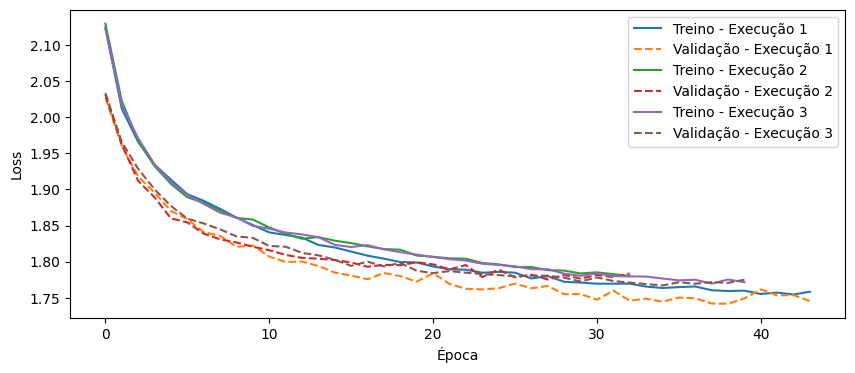

Execução 1:
  Treino — acurácia: 0.3716
  Teste  — loss: 1.7493, acurácia: 0.3729
Execução 2:
  Treino — acurácia: 0.3627
  Teste  — loss: 1.7786, acurácia: 0.3668
Execução 3:
  Treino — acurácia: 0.3641
  Teste  — loss: 1.7846, acurácia: 0.3619


In [53]:
# Resultados para dropout de 0.05
show_results(histories, train_accuracies, test_losses, test_accuracies)

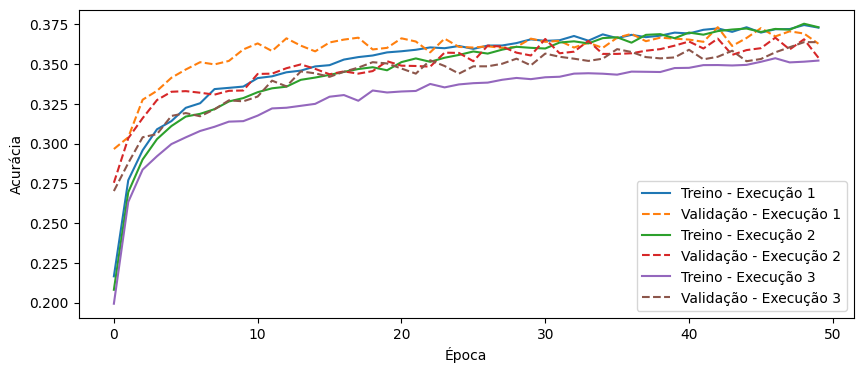

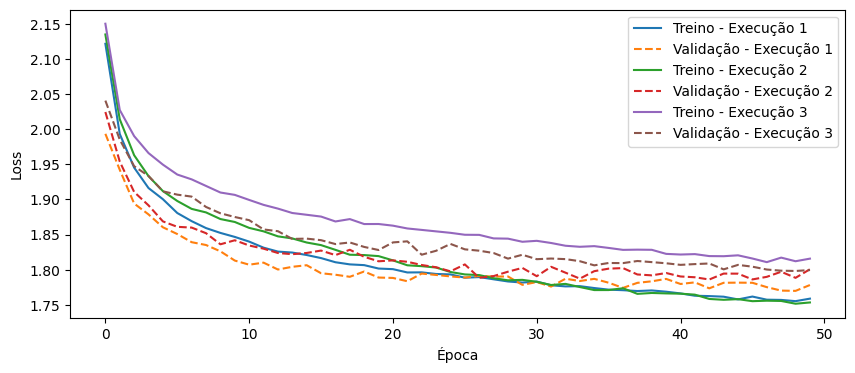

Execução 1:
  Treino — acurácia: 0.3729
  Teste  — loss: 1.7727, acurácia: 0.3679
Execução 2:
  Treino — acurácia: 0.3732
  Teste  — loss: 1.7911, acurácia: 0.3573
Execução 3:
  Treino — acurácia: 0.3522
  Teste  — loss: 1.7976, acurácia: 0.3565


In [ ]:
# Resultados para dropout de 0.05 # Camadas 
show_results(histories, train_accuracies, test_losses, test_accuracies)